In [ ]:
from transformers import pipeline

# Initialize the image-to-text pipeline with a pre-trained model
captioner = pipeline("image-to-text", model="nlpconnect/vit-gpt2-image-captioning")

In [6]:
# Provide a local file path or a URL to the image
result = captioner("4.jpg")

# Output the generated caption
print(result[0]['generated_text'])

a man is jumping a motorcycle in the air 


In [5]:
image_path = "4.jpg"

# Example 1: Adding "Noise" (High temperature, random sampling)
noisy_result = captioner(
    image_path, 
    generate_kwargs={
        "do_sample": True,
        "temperature": 1.4,  # High noise/creativity
        "top_k": 40,         # Safety net for the noise
        "max_new_tokens": 20 # Limit caption length
    }
)
print("Noisy/Creative Caption:", noisy_result[0]['generated_text'])

# Example 2: High Quality (Beam Search)
quality_result = captioner(
    image_path, 
    generate_kwargs={
        "do_sample": False,
        "num_beams": 5,      # Explores 5 paths to find the best overall caption
        "max_new_tokens": 20
    }
)
print("High-Quality Caption:", quality_result[0]['generated_text'])

Noisy/Creative Caption: lone person jumping the bike high in the air through the air 
High-Quality Caption: a person on a motorcycle jumping in the air 


In [2]:
# Part 14 — Full Pipeline: Image -> Text -> Custom Audio
import os
import torch
import soundfile as sf
import librosa
from transformers import pipeline, SpeechT5ForTextToSpeech, SpeechT5Processor, SpeechT5HifiGan
from speechbrain.pretrained import EncoderClassifier

# 1. Load the Image Captioning Model
print("Loading image captioning model...")
captioner = pipeline("image-to-text", model="nlpconnect/vit-gpt2-image-captioning", device="cuda" if torch.cuda.is_available() else "cpu")

# 2. Load your Fine-Tuned TTS Model
print("Loading your fine-tuned TTS model...")
model_path = "speecht5_finetuned_ljspeech/final" 
processor = SpeechT5Processor.from_pretrained(model_path)
model = SpeechT5ForTextToSpeech.from_pretrained(model_path)
vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")

# 3. Load the Real Voice Profile from your LJSpeech folder
print("Loading the human voice profile...")
spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-xvect-voxceleb",
    savedir="tmpdir",
    run_opts={"device": "cuda" if torch.cuda.is_available() else "cpu"}
)
audio_array, _ = librosa.load("./LJSpeech-1.1/wavs/LJ001-0001.wav", sr=16000)
audio_tensor = torch.tensor(audio_array).unsqueeze(0).float().to(spk_model.device)

with torch.no_grad():
    embedding = spk_model.encode_batch(audio_tensor)
    embedding = torch.nn.functional.normalize(embedding, dim=2)
    speaker_embeddings = embedding.squeeze().unsqueeze(0).to(model.device)

print("\n--- Pipeline Ready ---")

# 4. The Processing Engine (This is what your future UI will call)
def generate_caption_and_audio(image_path):
    print(f"\nProcessing image: {image_path}")
    
    # A. Look at the image and generate text
    print("1. Generating caption...")
    result = captioner(image_path)
    caption_text = result[0]['generated_text']
    print(f"   Result: '{caption_text}'")
    
    # B. Save the text to a file
    text_filename = "output_caption.txt"
    with open(text_filename, "w") as f:
        f.write(caption_text)
    print(f"2. Caption saved to {text_filename}")
    
    # C. Turn the text into speech using your trained model
    print("3. Generating audio...")
    inputs = processor(text=caption_text, return_tensors="pt")
    
    with torch.no_grad():
        speech = model.generate_speech(inputs["input_ids"].to(model.device), speaker_embeddings, vocoder=vocoder)
    
    # D. Save the speech to a .wav file
    audio_filename = "output_audio.wav"
    sf.write(audio_filename, speech.cpu().numpy(), samplerate=16000)
    print(f"4. Audio saved to {audio_filename}")
    
    print("\nProcess Complete! Both files are ready for your UI.")

# 5. Test the Engine!
# You can put a web link here, OR a local file path like "C:/Users/subra/Pictures/dog.jpg"
my_image_path = "./custom_img/2.jpg"

generate_caption_and_audio(my_image_path)

Loading image captioning model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading your fine-tuned TTS model...
Loading the human voice profile...

--- Pipeline Ready ---

Processing image: ./custom_img/2.jpg
1. Generating caption...


c:\Users\subra\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\generation\utils.py:1168: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


   Result: 'a man sitting on a boat in the water '
2. Caption saved to output_caption.txt
3. Generating audio...
4. Audio saved to output_audio.wav

Process Complete! Both files are ready for your UI.


Fetching results...


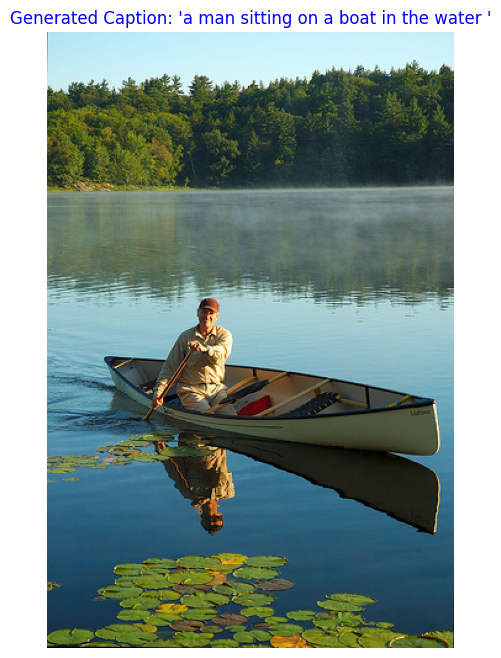


Listen to the generated audio:


In [3]:
# Part 15 — Displaying the Final Output
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from IPython.display import Audio, display

print("Fetching results...")

# 1. Read the caption we just saved
with open("output_caption.txt", "r") as f:
    saved_caption = f.read()

# 2. Load the image (this handles both web URLs and local files safely)
if my_image_path.startswith("http"):
    response = requests.get(my_image_path)
    img = Image.open(BytesIO(response.content))
else:
    img = Image.open(my_image_path)

# 3. Display the Image with the Caption as the title
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off') # Hides the grid lines
plt.title(f"Generated Caption: '{saved_caption}'", fontsize=12, wrap=True, color="blue")
plt.show()

# 4. Embed a playable audio widget!
print("\nListen to the generated audio:")
display(Audio("output_audio.wav"))